# Insurance Purchase Propensity Model

Binary classification model predicting vehicle insurance purchase likelihood for a portfolio of ~65,000 clients. The dataset is strongly imbalanced (12% purchasers / 88% non-purchasers), requiring systematic strategies to handle class imbalance without sacrificing business utility.

**Domain:** Insurance / Financial Services  
**Dataset:** 65,499 clients, 14 features (anonymized)  
**Task:** Binary classification — predict `Target` ∈ {0: non-purchase, 1: purchase}

In [1]:
from pandas.errors import InvalidIndexError
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
%matplotlib inline
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

import xgboost as xgb
from xgboost import XGBClassifier

### Load dataset

This dataset contains the original data and 2 new columns have been added: `region` and `kanal`. These 2 new columns are the categorized version of `RegionKod` and `SäljKanal`.

The `Target`variable takes the values 0 and 1.
  * 1 if the client buys an insurance
  * 0 if the client does not buy an insurance 

The dataset consist of 65499 clients (rows), 14 features(columns) and one last column that contains the variable 'Target' (What we want to predict)

In [2]:
df_ins=pd.read_csv('data_f.csv')
print(df_ins.shape)

(65499, 15)


We remove the outliers for Premie:
  * There is 1 value much larger than 400000, we remove it.

In [3]:
#Remove Outliers
df_ins=df_ins[(df_ins.Premie<400000)]

In [4]:
# Change data type for categorical variables
df_ins['Körkort']=df_ins['Körkort'].astype(str)
df_ins['HarMotorförsäkring']=df_ins['HarMotorförsäkring'].astype(str)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


### Features:
Choose the numerical variables:
* `Ålder`, `Premie`,`TidSomKund`, 

and the categorical variables:
* `Kön`, `Körkort`, `HarMotorförsäkring`, `FordonsÅlder`, `FordonsSkada`,`kanal`, `region`

Varible for prediction: `Target`


In [5]:
df_ins=df_ins[['Kön', 'Ålder', 'Körkort', 
       'HarMotorförsäkring', 'FordonsÅlder', 'FordonsSkada','Premie', 'TidSomKund',  'kanal', 'region','Target']]

In [6]:
df_ins.head()

,Kön,Ålder,Körkort,HarMotorförsäkring,FordonsÅlder,FordonsSkada,Premie,TidSomKund,kanal,region,Target
0,Man,44,1,0,Mer än två år,Ja,40454.0,217,kanal_26,region_28,1
1,Man,76,1,0,Ett till två år,Nej,33536.0,183,kanal_26,other_region,0
2,Man,47,1,0,Mer än två år,Ja,38294.0,27,kanal_26,region_28,1
3,Man,21,1,1,Mindre än ett år,Nej,28619.0,203,kanal_152,other_region,0
4,Kvinna,29,1,1,Mindre än ett år,Nej,27496.0,39,kanal_152,other_region,0


## Exploratory Data Analysis
### Unbalanced Data
#### Target
Only 12% of clients purchases a vehicle insurance (Target=1) and 88% do not purchase it (Target=0). The data is very unbalanced

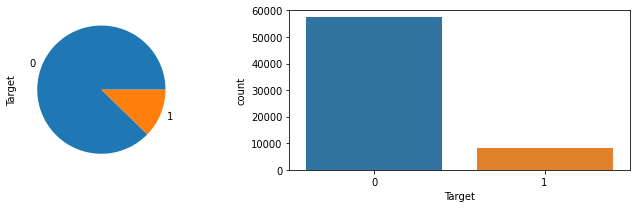

In [7]:
# chart for distribution of target variable
fig= plt.figure(figsize=(10,3) )
fig.add_subplot(1,2,1)
a= df_ins["Target"].value_counts(normalize=True).plot.pie()
fig.add_subplot(1,2,2)
churnchart=sns.countplot(x=df_ins["Target"])
plt.tight_layout()
plt.show()

In [8]:
df_ins["Target"].value_counts(normalize=True)

0    0.877231
1    0.122769
Name: Target, dtype: float64

### Summary of Frequencies:
The calculations are not shown here (I can send these too if you want to have a look)
#### Kön
* From those that buy an insurance approx 40% are females and 60% are males.
* 90% of females do not buy an insurance and 10% buy an insurance
* 86% of males do not buy an insurance and 14% buy an insurance

#### age_interval
* From those who buy an insurance 35% are between 40-50 y old, followed by 30-40 with 24%, 50-60 18%, 20-30 14%, 60+ 10%
* Age 20-30: 96% do not buy , 4% buy
* Age 30-40: 80% do not buy, 20% buy
* Age 40-50: 79% do not buy, 17% buy
* Age 50-60: 82% do not buy, 18% buy
* Age 60+: 90% do not buy, 10% buy

#### region
* From those who buy an insurance 44% are from region 28, 4% region 46, 7% region 8, and 45% from other regions
* Region 28: 81% do not buy, 19% buy
* Region 46: 90% do not buy, 10% buy
* Region 8: 91% do not buy, 9% buy
* other regions: 90% do not buy, 10% buy

#### FordonsÅlder
* From those that buy an insurance 75% have a 1-2 y old car, 15% less than 1 y, and 10% 2+ y
* FordonsÅlder < 1 y: 96% do not buy, 4% buy
* FordonsÅlder 1-2 y: 83% do not buy, 17% buy
* FordonsÅlder 2+: 70% do not buy, 30% buy

#### kanal
* From those that buy an insurance 34% arrives from kanal 26, 30% from kanal 124, 28% other kanal and 8% from kanal 152
* kanal 26: 80% do not buy, 20% buy
* kanal 124: 81% do not buy 19% buy
* other kanal: 86% do not buy, 14% buy
* kanal 152: 97% do not buy, 3% buy

#### premie_interval
* From those that buy an insurance 19% have premium between 10-20k, 52% between 20-40k, 25% between 40-60k, 3% between 60-80k, and 0.8% 80k+
* premie between 0-20k: 87% do not buy, 12% buy
* premie between 20k-40k: 89% do not buy, 11% buy
* premie between 40k-60k: 85% do not buy, 15% buy
* premie between 60k-80k: 85% do not buy, 15% buy
* premie 80k+: 83% do not buy, 17% buy


### Numerical Variables: Statistics, Boxplots and Histograms
* `Ålder`, `Premie`,`TidSomKund`

Statistics for purchasers and non-purchasers
#### 1. Purchasers

In [9]:
descr=df_ins[['Ålder','Premie',  'TidSomKund','Target']]
descr[descr.Target==1].describe()

,Ålder,Premie,TidSomKund,Target
count,8041.000000,8041.000000,8041.000000,8041.0
mean,43.339137,31811.020520,154.909588,1.0
std,12.104326,19009.355741,84.257156,0.0
min,20.000000,2630.000000,10.000000,1.0
25%,35.000000,24842.000000,81.000000,1.0
50%,43.000000,33206.000000,155.000000,1.0
75%,51.000000,41354.000000,227.000000,1.0
max,81.000000,340439.000000,299.000000,1.0


#### 2. Non-Purchasers

In [10]:
descr[descr.Target==0].describe()

,Ålder,Premie,TidSomKund,Target
count,57456.000000,57456.000000,57456.000000,57456.0
mean,38.116907,30336.216339,154.309889,0.0
std,15.832677,16580.019185,83.713942,0.0
min,20.000000,2630.000000,10.000000,0.0
25%,24.000000,24300.750000,82.000000,0.0
50%,33.000000,31510.000000,154.000000,0.0
75%,49.000000,39212.250000,227.000000,0.0
max,85.000000,315565.000000,299.000000,0.0


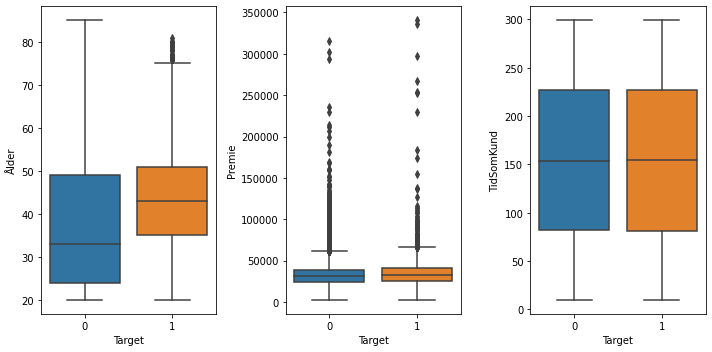

In [11]:
# Visualize relationship between promoted and other features
fig= plt.figure(figsize=(10,5) )
fig.add_subplot(1,3,1)
ar_6=sns.boxplot(x=df_ins["Target"],y=df_ins["Ålder"])
fig.add_subplot(1,3,2)
ar_6=sns.boxplot(x=df_ins["Target"],y=df_ins["Premie"])
fig.add_subplot(1,3,3)
ar_6=sns.boxplot(x=df_ins["Target"],y=df_ins["TidSomKund"])
plt.tight_layout()
plt.show()

<Figure size 1152x864 with 0 Axes>

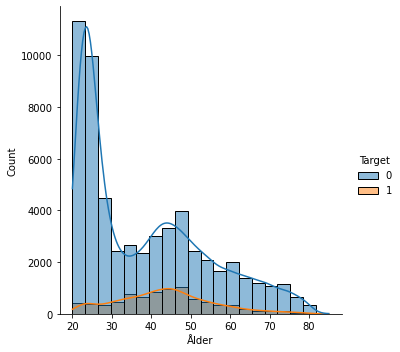

In [12]:
# Plot the histogram based on age and output value
fig= plt.figure(figsize=(16,12) )
ax=sns.displot(data=df_ins, x='Ålder', hue='Target', kde=True, bins=20)

(0.0, 100000.0)

<Figure size 1152x1440 with 0 Axes>

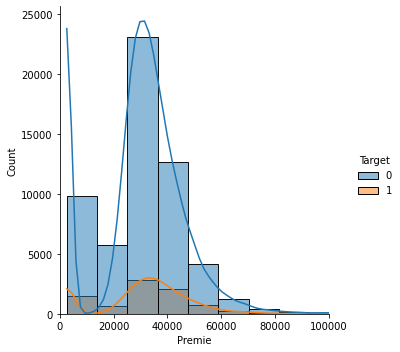

In [13]:
# Plot the histogram based on age and output value
fig= plt.figure(figsize=(16,20) )
ax=sns.displot(data=df_ins, x='Premie', hue='Target', kde=True, bins=30)
plt.xlim(0,100000)

<Figure size 1152x1440 with 0 Axes>

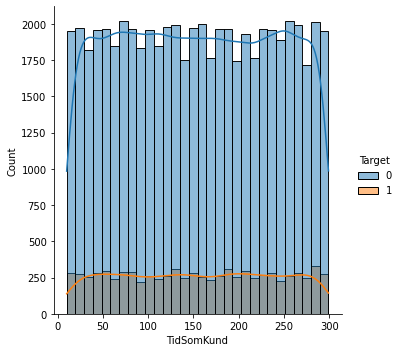

In [14]:
# Plot the histogram based on age and output value
fig= plt.figure(figsize=(16,20) )
ax=sns.displot(data=df_ins, x='TidSomKund', hue='Target', kde=True, bins=30)

#### Ålder:
The box-plot shows that the spread of ages is wider for the non-purchaser that for the purchasers and that the median age of purchasers is around 43 years and 33 years for non-purchasers
#### Premie
There are many outliers. However. The distribution for purchasers and non-purchasers is very. similar and the medians for both are pretty similar, approximately 30000 kr.
#### TidSomKund
The distribution is similar in both groups. The median for purchasers and non-purchasers is 150 days (~5 months)

### Categorical Variables: 
* `Kön`,  `Körkort`, `HarMotorförsäkring`, `FordonsÅlder`,`FordonsSkada`,`kanal`, `region`
#### Count Plots

In [15]:
cat_var=df_ins[['Kön',  'Körkort', 'HarMotorförsäkring', 'FordonsÅlder',
       'FordonsSkada', 'kanal', 'region']]

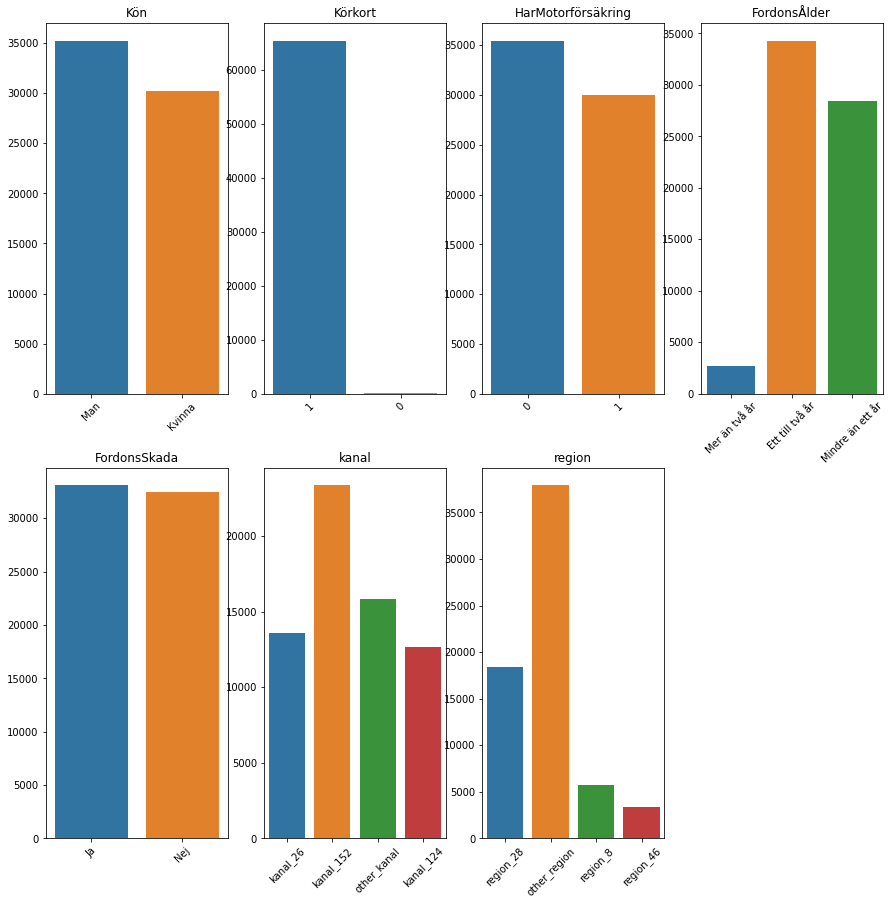

In [16]:
# Countplot of categorial variables
fig = plt.figure(figsize=(15,15))
for i, col in enumerate(cat_var):
    axi = plt.subplot(2, 4, i+1)
    sns.countplot(ax=axi, data=df_ins, x=col).set_title(col)
    axi.set_xlabel('')
    axi.set_ylabel('')
    plt.xticks(rotation=45)

#### Count Plots Purchasers/Non-Purchasers

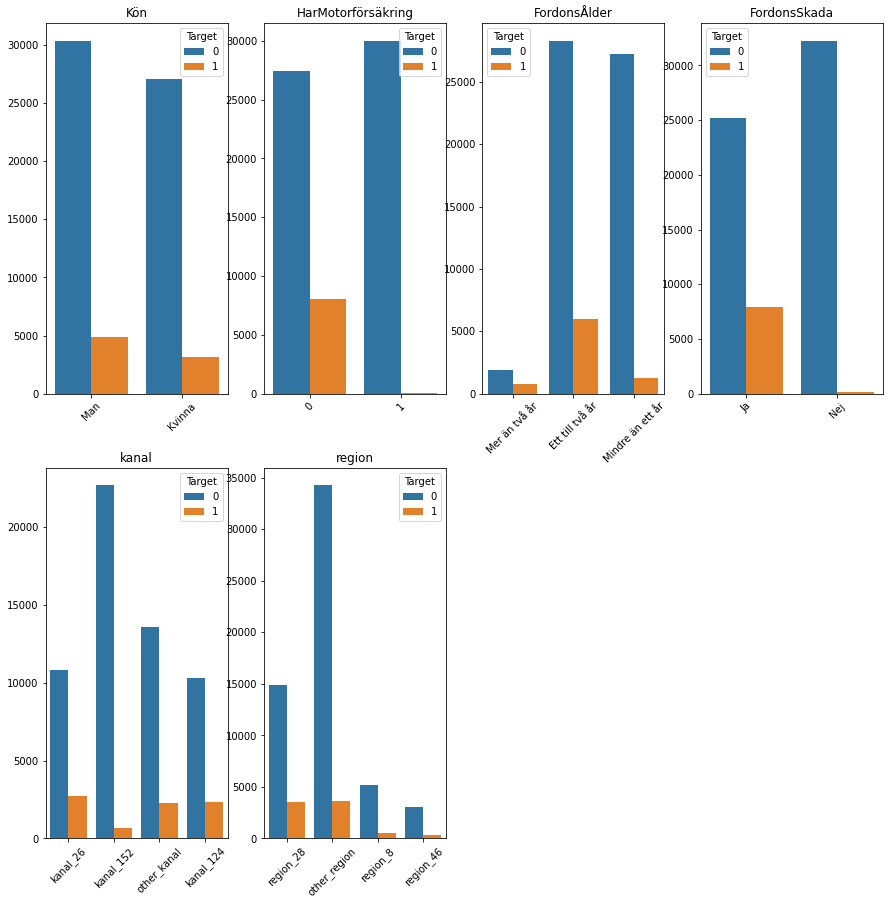

In [17]:
# Countplot of categorial variables
cat_var=df_ins[['Kön',  'HarMotorförsäkring', 'FordonsÅlder',
       'FordonsSkada', 'kanal', 'region']]
fig = plt.figure(figsize=(15,15))
for i, col in enumerate(cat_var):
    axi = plt.subplot(2, 4, i+1)
    sns.countplot(ax=axi, data=df_ins, x=col, hue='Target').set_title(col)
    axi.set_xlabel('')
    axi.set_ylabel('')
    plt.xticks(rotation=45)

#### Variable KörtKort

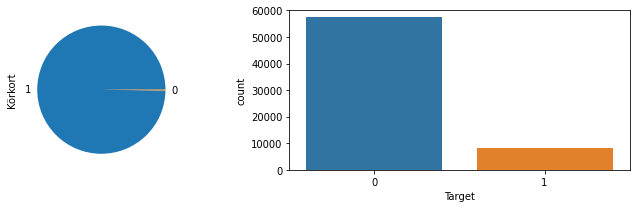

In [18]:
# cchart for distribution of target variable
fig= plt.figure(figsize=(10,3) )
fig.add_subplot(1,2,1)
a= df_ins["Körkort"].value_counts(normalize=True).plot.pie()
fig.add_subplot(1,2,2)
churnchart=sns.countplot(x=df_ins["Target"])
plt.tight_layout()
plt.show()

In [19]:
print(df_ins["Körkort"].value_counts(normalize=True))
print(df_ins["Körkort"].value_counts())

1    0.997817
0    0.002183
Name: Körkort, dtype: float64
1    65354
0      143
Name: Körkort, dtype: int64


Only 0.2% of users do not have "Körkort", and in principle it is very unlikely that some one will buy a Motor Insurance without "Körkort". I will **not consider the column "Körkort" and I'll remove all rows of users that do not have "Körkort"**

### Variable Motorförsäkring

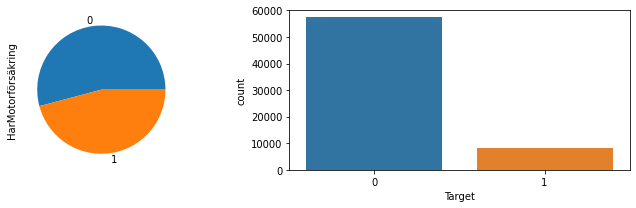

In [20]:
# cchart for distribution of target variable
fig= plt.figure(figsize=(10,3) )
fig.add_subplot(1,2,1)
a= df_ins["HarMotorförsäkring"].value_counts(normalize=True).plot.pie()
fig.add_subplot(1,2,2)
churnchart=sns.countplot(x=df_ins["Target"])
plt.tight_layout()
plt.show()

In [21]:
print(df_ins["HarMotorförsäkring"].value_counts(normalize=True))
print(df_ins["HarMotorförsäkring"].value_counts())

0    0.541368
1    0.458632
Name: HarMotorförsäkring, dtype: float64
0    35458
1    30039
Name: HarMotorförsäkring, dtype: int64


The feature "HarMotorförsäkring" seems to be important. Do not reject

In [22]:
df_ins=df_ins[df_ins["Körkort"]=='1']

In [23]:
df_ins=df_ins[['Kön', 'Ålder','HarMotorförsäkring', 'FordonsÅlder',
       'FordonsSkada', 'Premie', 'TidSomKund', 'kanal', 'region', 'Target']]

## Data Preparation. One Hot Encoding
Use One-Hot encoding to create a column for each category with 0s and 1s

In [24]:
# Create two data sets for numeric and non-numeric data
ins_num = df_ins.select_dtypes(exclude=['object'])
ins_str= df_ins.select_dtypes(include=['object'])

# One-hot encode the non-numeric columns
ins_str_onehot = pd.get_dummies(ins_str)

# Union the one-hot encoded columns to the numeric ones
ins_prep = pd.concat([ins_num, ins_str_onehot], axis=1)

#Print first 5 rows
ins_prep.head(5)

,Ålder,Premie,TidSomKund,Target,Kön_Kvinna,Kön_Man,HarMotorförsäkring_0,HarMotorförsäkring_1,FordonsÅlder_Ett till två år,FordonsÅlder_Mer än två år,...,FordonsSkada_Ja,FordonsSkada_Nej,kanal_kanal_124,kanal_kanal_152,kanal_kanal_26,kanal_other_kanal,region_other_region,region_region_28,region_region_46,region_region_8
0,44,40454.0,217,1,0,1,1,0,0,1,...,1,0,0,0,1,0,0,1,0,0
1,76,33536.0,183,0,0,1,1,0,1,0,...,0,1,0,0,1,0,1,0,0,0
2,47,38294.0,27,1,0,1,1,0,0,1,...,1,0,0,0,1,0,0,1,0,0
3,21,28619.0,203,0,0,1,0,1,0,0,...,0,1,0,1,0,0,1,0,0,0
4,29,27496.0,39,0,1,0,0,1,0,0,...,0,1,0,1,0,0,1,0,0,0


#### Keep only Region 28 and Kanal 26 and kanal 124
We know that:
1. Region: 
* Region 28 accounts for 44% of those that buy an insurance
* 20% of all users from 28 buy an insurance (above the 12% average)

2. Kanal:
* kanal 26 and 124 accounts for 34% and 33% of those that buy insurance
* Approximately 20% of users from kanal 26 and 124 buy an insurance (above the 12% average)

For these reason I weill only keep the columns `region_28`and `kanal_kanal_26` and `kanal_kanal_124`


In [25]:
ins_prep=ins_prep[['Ålder', 'Premie', 'TidSomKund', 'Target', 'Kön_Kvinna', 'Kön_Man',
       'HarMotorförsäkring_0', 'HarMotorförsäkring_1',
       'FordonsÅlder_Ett till två år', 'FordonsÅlder_Mer än två år',
       'FordonsÅlder_Mindre än ett år', 'FordonsSkada_Ja', 'FordonsSkada_Nej',
       'kanal_kanal_124', 'kanal_kanal_26', 'region_region_28']]

## Train-Test Split
We will divide the dataset into two subsets: train and test. 
To perform the train-test split, we’ll use Scikit-learn machine learning.

* Train subset – we will use this subset to fit/train the model
* Test subset – we will use this subset to evaluate our model

Split data into dependent variables(X) and independent variable(y) that we would predict

In [26]:
y=ins_prep[['Target']]

In [27]:
X=ins_prep.drop(['Target'], axis=1)

In [28]:
#Let’s split X and y using Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=123,train_size=0.8)
#get shape of train and test data
print("train size X : ",X_train.shape)
print("train size y : ",y_train.shape)
print("test size X : ",X_test.shape)
print("test size y : ",y_test.shape)

train size X :  (52283, 15)
train size y :  (52283, 1)
test size X :  (13071, 15)
test size y :  (13071, 1)


## Feature Scaling/Normalization

Standarization Technique: The features will be scaled to have a mean of 0 and a standard deviation of 1
We use this method since the numerical variables are very different in magnitude. 

In [29]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

### Class Imbalance 

In [30]:
y_train.value_counts(normalize=True)

Target
0         0.876499
1         0.123501
dtype: float64

The majority of the labels are from class 0 and only a few are from class 1.

If we use this distribution to develop our model, it may become biased towards predicting the majority class since there will be insufficient data to learn minority class patterns. The model will start predicting every new observation as 0 or majority class.

We must consider class imbalance when developing our Logistic Regression model.

## Logistic Regression
### 1. Logistic Regression baseline. 
We slightly penalize the class 0, givig a weight of 0.4 for class 0 and 0.6 for class 1 

In [31]:
#import library
from sklearn.linear_model import LogisticRegression
#make instance of model with default parameters except class weight
#as we will add class weights due to class imbalance problem
lr_basemodel=LogisticRegression(solver='lbfgs', class_weight={0:0.4,1:0.6}).fit(X_train,np.ravel(y_train))

In [32]:
y_pred_basemodel= lr_basemodel.predict(X_test)

#### F1 Score, Confusion Matrix and Classification Report

In [33]:
from sklearn.metrics import f1_score
print("f1 score for base model is : " , f1_score(y_test,y_pred_basemodel))

f1 score for base model is :  0.07912844036697249


[[11396   101]
 [ 1505    69]]


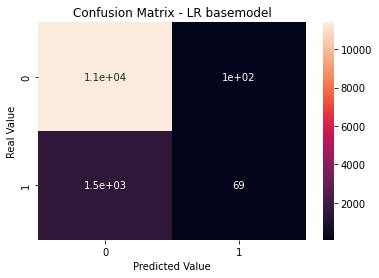

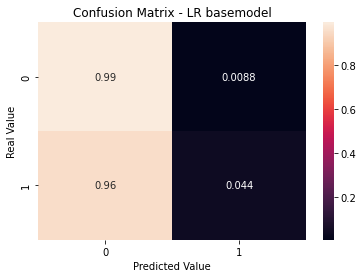

In [34]:
# Create predictions of probability for purcahse status using test data
lr_basemodel_preds= lr_basemodel.predict(X_test)

# Create a dataframe for the predictions of purchase
preds_df_lr_basemodel = pd.DataFrame(lr_basemodel_preds, columns = ['purchase_status'])
print(confusion_matrix(y_test,preds_df_lr_basemodel['purchase_status']))

fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(y_test,preds_df_lr_basemodel['purchase_status']),annot=True)
ax.set_title('Confusion Matrix - LR basemodel')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Real Value');
plt.show();

fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(y_test,preds_df_lr_basemodel['purchase_status'],normalize='true'),annot=True)
ax.set_title('Confusion Matrix - LR basemodel')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Real Value');

In [35]:
# Create a dataframe for the probabilities of purchase
preds_basemodel = pd.DataFrame(y_pred_basemodel, columns = ['purchase_status'])

In [36]:
# Print the classification report
target_names = ['Non-Purchase', 'Purchase']
print(classification_report(y_test, preds_basemodel['purchase_status'], target_names=target_names))

              precision    recall  f1-score   support

Non-Purchase       0.88      0.99      0.93     11497
    Purchase       0.41      0.04      0.08      1574

    accuracy                           0.88     13071
   macro avg       0.64      0.52      0.51     13071
weighted avg       0.83      0.88      0.83     13071



Although the recall for Non-purchasers is 99%, the model underperforms and it only catches 4% of the True Positives. 
We need to catch more true positives.

### Cross Validation: Hyperparameter Optimization for the Logistic Regression Model

To get a better model we will use Grid Search which, a method of searching optimal values for hyperparameters. 

Hyperparameters Tunning steps:

* Create a model instance of the Logistic Regression class
* Specify hyperparameters with all possible values
* Define performance evaluation metrics
* Apply cross-validation
* Train the model using the training dataset
* Determine the best values for the hyperparameters given.

In [37]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
#Hyperparameter tuning
# define model/create instance
lr=LogisticRegression(solver='lbfgs')
#tuning weight for minority class then weight for majority class will be 1-weight of minority class
#Setting the range for class weights
weights = np.linspace(0.0,0.99,100)
#specifying all hyperparameters with possible values
param= {'C': [10], 'penalty': ['l2'],"class_weight":[{0:x ,1:1.0 -x} for x in weights]}
# create 5 folds
folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
#Gridsearch for hyperparam tuning
model= GridSearchCV(estimator= lr,param_grid=param,scoring="f1",cv=folds,return_train_score=True)
#train model to learn relationships between x and y
model.fit(X_train,np.ravel(y_train))

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
             estimator=LogisticRegression(),
             param_grid={'C': [10],
                         'class_weight': [{0: 0.0, 1: 1.0}, {0: 0.01, 1: 0.99},
                                          {0: 0.02, 1: 0.98},
                                          {0: 0.03, 1: 0.97},
                                          {0: 0.04, 1: 0.96},
                                          {0: 0.05, 1: 0.95},
                                          {0: 0.06, 1: 0.94},
                                          {0: 0.07, 1: 0.9299999999999999},
                                          {0: 0.08, 1: 0.92},
                                          {0: 0.09, 1: 0.91}, {0: 0.1, 1: 0.9},
                                          {0: 0.11, 1: 0.89},
                                          {0: 0.1...0.88},
                                          {0: 0.13, 1: 0.87},
                                          {0: 0.14,

In [38]:
# print best hyperparameters
print("Best F1 score: ", model.best_score_)
print("Best hyperparameters: ", model.best_params_)

Best F1 score:  0.43747670190776056
Best hyperparameters:  {'C': 10, 'class_weight': {0: 0.22, 1: 0.78}, 'penalty': 'l2'}


### Build Model using optimal values of Hyperparameters

In [39]:
#Building Model again with best params
lr2=LogisticRegression(class_weight={0:0.22,1:0.78},C=20,penalty="l2")
lr_model2=lr2.fit(X_train,np.ravel(y_train))


In [40]:
y_pred_model2= lr_model2.predict(X_test)
print("f1 score for base model is : " , f1_score(y_test,y_pred_model2))

f1 score for base model is :  0.4331678617392903


The model has improved a lot. In the previous model the f1-score was 0.08 and now the f1-score is 0.43

#### Logistic Regression's ROC Curve and AUC

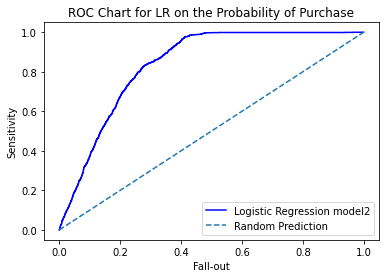

LR model2 AUC= 0.84


In [41]:
# Create predictions and store them in a variable
# lr model2
lr_model2_preds_proba = lr_model2.predict_proba(X_test)
lr_model2_preds_proba=lr_model2_preds_proba[:,1]

# lr model base
#lr_basemodel_preds = lr_basemodel.predict_proba(X_test)
#lr_basemodel_preds=lr_basemodel_preds[:,1]


# ROC chart components
fallout_lr2, sensitivity_lr2, thresholds_lr2 = roc_curve(y_test,lr_model2_preds_proba)
#fallout_lr_base, sensitivity_lr_base, thresholds_lr_base = roc_curve(y_test,lr_basemodel_preds)

# ROC Chart with both
plt.plot(fallout_lr2, sensitivity_lr2, color = 'blue', label='%s' % 'Logistic Regression model2')
#plt.plot(fallout_lr_base, sensitivity_lr_base, color = 'green', label='%s' % 'Logistic Regression base model')
plt.plot([0, 1], [0, 1], linestyle='--', label='%s' % 'Random Prediction')
plt.title("ROC Chart for LR on the Probability of Purchase")
plt.xlabel('Fall-out')
plt.ylabel('Sensitivity')
plt.legend()
plt.show()

# Compute the AUC and store it in a variable
auc = roc_auc_score(y_test, lr_model2_preds_proba)
print('LR model2 AUC=',auc.round(2))
#auc = roc_auc_score(y_test, lr_basemodel_preds)
#print('LR Base Model AUC=',auc.round(2))

In [42]:
# Create predictions of probability for purcahse status using test data
lr_model2_preds= lr_model2.predict(X_test)

# Create a dataframe for the predictions of purchase
preds_df_lr_model2 = pd.DataFrame(lr_model2_preds, columns = ['purchase_status'])

# Print the classification report
target_names = ['Non-Purchase', 'Purchase']
print(classification_report(y_test, preds_df_lr_model2['purchase_status'], target_names=target_names))

              precision    recall  f1-score   support

Non-Purchase       0.96      0.77      0.85     11497
    Purchase       0.30      0.75      0.43      1574

    accuracy                           0.76     13071
   macro avg       0.63      0.76      0.64     13071
weighted avg       0.88      0.76      0.80     13071



[[8810 2687]
 [ 396 1178]]


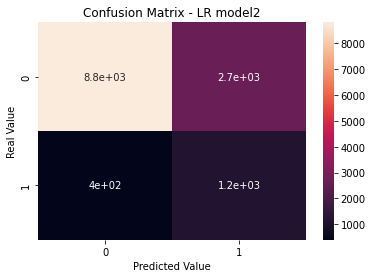

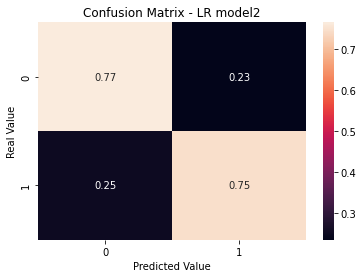

In [43]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,preds_df_lr_model2['purchase_status']))

fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(y_test,preds_df_lr_model2['purchase_status']),annot=True)
ax.set_title('Confusion Matrix - LR model2')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Real Value');
plt.show();
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(y_test, preds_df_lr_model2['purchase_status'], normalize='true'), annot=True, ax=ax)
ax.set_title('Confusion Matrix - LR model2')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Real Value');

In addition to the `intercept_`, which is an attribute of the model, `LogisticRegression()` models also have the `.coef_ attribute`. This shows how important each training column is for predicting the probability of default.

In [44]:
# Print the models coefficients
print('Logistic Regression coeff: ',lr_model2.coef_)
#Intercept
print('Logistic Regression intercapt: ',lr_model2.intercept_)

Logistic Regression coeff:  [[-0.40839725  0.0150388   0.00653031 -0.01740509  0.01740509  0.89845287
  -0.89845287  0.24999086  0.13763466 -0.30730976  0.52383617 -0.52383617
   0.08722313  0.17239911  0.09669809]]
Logistic Regression intercapt:  [-2.74834054]


In [45]:
b=pd.DataFrame(X.columns.to_list(),columns=['features'])
b['coef']=lr_model2.coef_.flatten()
b.sort_values(['coef'],ascending=False)

,features,coef
5,HarMotorförsäkring_0,0.898453
10,FordonsSkada_Ja,0.523836
7,FordonsÅlder_Ett till två år,0.249991
13,kanal_kanal_26,0.172399
8,FordonsÅlder_Mer än två år,0.137635
14,region_region_28,0.096698
12,kanal_kanal_124,0.087223
4,Kön_Man,0.017405
1,Premie,0.015039
2,TidSomKund,0.006530


### Logistic Regression with Undersampling
Undersample the training set
Prepare a training set that has the same number of purchase and non-purchase. Choose randomly the non-purchase rows.

In [46]:
# Create X_y_train dataframe necessary to create undersampling data
X_y_train=pd.DataFrame(X_train, columns=X.columns)
X_y_train['purchase_status']=np.ravel(y_train)

# Create data sets for purchase and purchase
nonpurchases = X_y_train[X_y_train['purchase_status'] == 0]
purchases = X_y_train[X_y_train['purchase_status'] == 1]
num_purchases=purchases.purchase_status.count()

# Undersample the non-defaults
nonpurchases_under = nonpurchases.sample(num_purchases)

# Concatenate the undersampled nondefaults with defaults
X_y_train_under = pd.concat([nonpurchases_under.reset_index(drop = True),
                             purchases.reset_index(drop = True)], axis = 0)

# Print the value counts for loan status
print(X_y_train_under['purchase_status'].value_counts())

y_train_under=X_y_train_under['purchase_status']
X_train_under=X_y_train_under.drop(columns=['purchase_status'])

0    6457
1    6457
Name: purchase_status, dtype: int64


This dataset contains 6457 purchase-status=1 and 6457 purchase_status=0
#### Logistic Regression with undesampling Hyperparameter Tunning

In [47]:
#Hyperparameter tuning
# define model/create instance
lr=LogisticRegression(solver='lbfgs')

#tuning weight for minority class then weight for majority class will be 1-weight of minority class
#Setting the range for class weights
weights = np.linspace(0.0,0.99,100)

#specifying all hyperparameters with possible values
param= {'C': [10], 'penalty': ['l2'],"class_weight":[{0:x ,1:1.0 -x} for x in weights]}

# create 7 folds
folds = StratifiedKFold(n_splits = 7, shuffle = True, random_state = 123)

#Gridsearch for hyperparam tuning
model_under= GridSearchCV(estimator= lr,param_grid=param,scoring="f1",cv=folds,return_train_score=True)

#train model to learn relationships between x and y
model_under.fit(X_train_under,np.ravel(y_train_under))

GridSearchCV(cv=StratifiedKFold(n_splits=7, random_state=123, shuffle=True),
             estimator=LogisticRegression(),
             param_grid={'C': [10],
                         'class_weight': [{0: 0.0, 1: 1.0}, {0: 0.01, 1: 0.99},
                                          {0: 0.02, 1: 0.98},
                                          {0: 0.03, 1: 0.97},
                                          {0: 0.04, 1: 0.96},
                                          {0: 0.05, 1: 0.95},
                                          {0: 0.06, 1: 0.94},
                                          {0: 0.07, 1: 0.9299999999999999},
                                          {0: 0.08, 1: 0.92},
                                          {0: 0.09, 1: 0.91}, {0: 0.1, 1: 0.9},
                                          {0: 0.11, 1: 0.89},
                                          {0: 0.1...0.88},
                                          {0: 0.13, 1: 0.87},
                                          {0: 0.14,

In [48]:
# print best hyperparameters
print("Best F1 score: ", model_under.best_score_)
print("Best hyperparameters: ", model_under.best_params_)

Best F1 score:  0.8190282075229306
Best hyperparameters:  {'C': 10, 'class_weight': {0: 0.41000000000000003, 1: 0.59}, 'penalty': 'l2'}


In [49]:
#Building Model again with best params
lr_und=LogisticRegression(class_weight={0: 0.41000000000000003, 1: 0.59},C=10,penalty="l2")
lr_under=lr_und.fit(X_train_under,np.ravel(y_train_under))

              precision    recall  f1-score   support

Non-Purchase       0.99      0.59      0.74     11497
    Purchase       0.24      0.98      0.39      1574

    accuracy                           0.63     13071
   macro avg       0.62      0.78      0.56     13071
weighted avg       0.90      0.63      0.70     13071



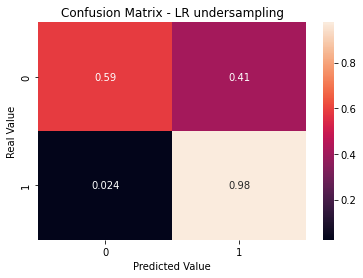

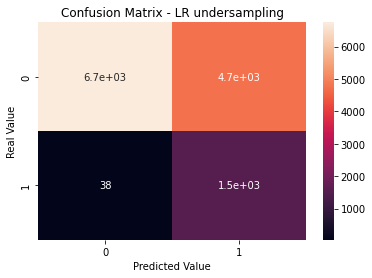

In [50]:
# Create predictions of probability for purcahse status using test data
X_test_df=pd.DataFrame(X_test, columns=X_train_under.columns)
lr_under_preds= lr_under.predict(X_test_df)

# Create a dataframe for the predictions of purchase
preds_df_lr_under = pd.DataFrame(lr_under_preds, columns = ['purchase_status'])

# Print the classification report
target_names = ['Non-Purchase', 'Purchase']
print(classification_report(y_test, preds_df_lr_under['purchase_status'], target_names=target_names))

# confusion matrix
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(y_test, preds_df_lr_under['purchase_status'], normalize='true'), annot=True, ax=ax)
ax.set_title('Confusion Matrix - LR undersampling')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Real Value');
plt.show()
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(y_test, preds_df_lr_under['purchase_status']), annot=True, ax=ax)
ax.set_title('Confusion Matrix - LR undersampling')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Real Value');

In [51]:
b=pd.DataFrame(X.columns.to_list(),columns=['features'])
b['coef']=lr_under.coef_.flatten()
b.sort_values(['coef'],ascending=False)

,features,coef
5,HarMotorförsäkring_0,0.894511
10,FordonsSkada_Ja,0.513741
7,FordonsÅlder_Ett till två år,0.226189
8,FordonsÅlder_Mer än två år,0.158069
13,kanal_kanal_26,0.127850
14,region_region_28,0.103640
12,kanal_kanal_124,0.082287
4,Kön_Man,0.017947
2,TidSomKund,0.007429
1,Premie,0.003501


# Extrem Gradient Boost: XGTBoost

The XGB method do not requires data normalization.

### Train and Test sets

In [52]:
#Let’s split X and y using Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=123,train_size=0.8)
#get shape of train and test data
print("train size X : ",X_train.shape)
print("train size y : ",y_train.shape)
print("test size X : ",X_test.shape)
print("test size y : ",y_test.shape)

train size X :  (52283, 15)
train size y :  (52283, 1)
test size X :  (13071, 15)
test size y :  (13071, 1)


In [53]:
# Train a model
import xgboost as xgb
clf_gbt = xgb.XGBClassifier().fit(X_train, np.ravel(y_train))

# Predict with a model
gbt_preds_proba = clf_gbt.predict_proba(X_test)

# Create datafram
preds_proba_df_gbt = pd.DataFrame(gbt_preds_proba[:,1], columns = ['prob_purchase'])
true_df_gbt = y_test


#### Prediction. Use the same weights than for the Logistic Regression
* 1 if probability is > 0.22

0    8979
1    4092
Name: purchase_status, dtype: int64
              precision    recall  f1-score   support

Non-Purchase       0.96      0.75      0.85     11497
    Purchase       0.31      0.80      0.44      1574

    accuracy                           0.76     13071
   macro avg       0.64      0.77      0.64     13071
weighted avg       0.89      0.76      0.80     13071

[[8659 2838]
 [ 320 1254]]


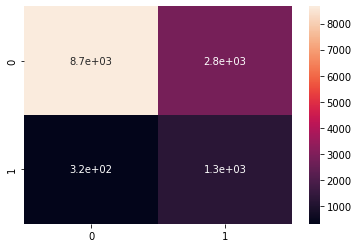

[[8659 2838]
 [ 320 1254]]


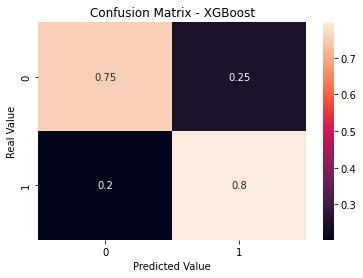

In [54]:
# Reassign purchase status based on the threshold
preds_df_gbt=pd.DataFrame([])
preds_df_gbt['purchase_status'] = preds_proba_df_gbt['prob_purchase'].apply(lambda x: 1 if x > 0.22 else 0)

# Print the row counts for each loan status
print(preds_df_gbt['purchase_status'].value_counts())

# Print the classification report
target_names = ['Non-Purchase', 'Purchase']
print(classification_report(y_test, preds_df_gbt['purchase_status'], target_names=target_names))
print(confusion_matrix(y_test,preds_df_gbt['purchase_status']))
sns.heatmap(confusion_matrix(y_test,preds_df_gbt['purchase_status']), annot=True);
ax.set_title('Confusion Matrix - XGBoost');
ax.set_xlabel('Predicted Value');
ax.set_ylabel('Real Value');
plt.show()

print(confusion_matrix(y_test,preds_df_gbt['purchase_status']))
ax=sns.heatmap(confusion_matrix(y_test,preds_df_gbt['purchase_status'], normalize='true'), annot=True);
ax.set_title('Confusion Matrix - XGBoost');
ax.set_xlabel('Predicted Value');
ax.set_ylabel('Real Value');

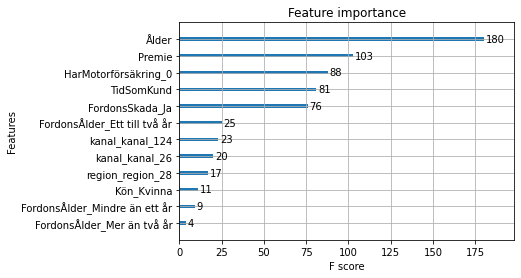

In [55]:
# Plot the column importance for this model
xgb.plot_importance(clf_gbt, importance_type = 'weight')
plt.show()

## XGTBoost Undersampling

In [56]:
# Create X_y_train dataframe necessary to create undersampling data
X_y_train=X_train
X_y_train['purchase_status']=np.ravel(y_train)

# Create data sets for purchase and purchase
nonpurchases_gbt = X_y_train[X_y_train['purchase_status'] == 0]
purchases_gbt = X_y_train[X_y_train['purchase_status'] == 1]
num_purchases_gbt=purchases.purchase_status.count()

# Undersample the non-defaults
nonpurchases_under_gbt = nonpurchases_gbt.sample(num_purchases)

# Concatenate the undersampled nondefaults with defaults
X_y_train_under_gbt = pd.concat([nonpurchases_under_gbt.reset_index(drop = True),
                             purchases_gbt.reset_index(drop = True)], axis = 0)

# Print the value counts for loan status
print(X_y_train_under_gbt['purchase_status'].value_counts())

y_train_under_gbt=X_y_train_under_gbt['purchase_status']
X_train_under_gbt=X_y_train_under_gbt.drop(columns=['purchase_status'])

0    6457
1    6457
Name: purchase_status, dtype: int64


In [57]:
# Train model
clf_gbt_under = xgb.XGBClassifier().fit(X_train_under_gbt, np.ravel(y_train_under_gbt))

# Predict with a model
gbt_under_preds_proba = clf_gbt_under.predict_proba(X_test)

# Create datafram
preds_proba_df_gbt_under = pd.DataFrame(gbt_under_preds_proba[:,1], columns = ['prob_purchase'])
true_df_gbt = y_test

1    6576
0    6495
Name: purchase_status, dtype: int64
              precision    recall  f1-score   support

Non-Purchase       1.00      0.56      0.72     11497
    Purchase       0.24      0.99      0.38      1574

    accuracy                           0.61     13071
   macro avg       0.62      0.78      0.55     13071
weighted avg       0.91      0.61      0.68     13071

[[6475 5022]
 [  20 1554]]


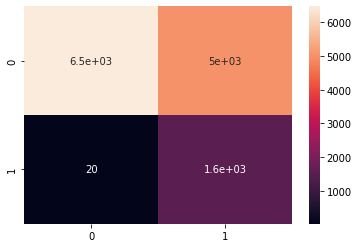

[[6475 5022]
 [  20 1554]]


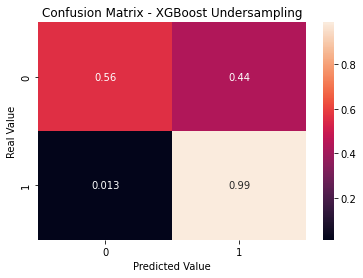

In [58]:
# Reassign purchase status based on the threshold
preds_df_gbt_under=pd.DataFrame([])
preds_df_gbt_under['purchase_status'] = preds_proba_df_gbt_under['prob_purchase'].apply(lambda x: 1 if x > 0.21 else 0)

# Print the row counts for each loan status
print(preds_df_gbt_under['purchase_status'].value_counts())

# Print the classification report
target_names = ['Non-Purchase', 'Purchase']
print(classification_report(y_test, preds_df_gbt_under['purchase_status'], target_names=target_names))

#Print Confusion Matrix
print(confusion_matrix(y_test,preds_df_gbt_under['purchase_status']))
sns.heatmap(confusion_matrix(y_test,preds_df_gbt_under['purchase_status']), annot=True);
ax.set_title('Confusion Matrix - XGBoost 2');
ax.set_xlabel('Predicted Value');
ax.set_ylabel('Real Value');
plt.show()

print(confusion_matrix(y_test,preds_df_gbt_under['purchase_status']))
ax=sns.heatmap(confusion_matrix(y_test,preds_df_gbt_under['purchase_status'], normalize='true'), annot=True);
ax.set_title('Confusion Matrix - XGBoost Undersampling');
ax.set_xlabel('Predicted Value');
ax.set_ylabel('Real Value');
plt.show()

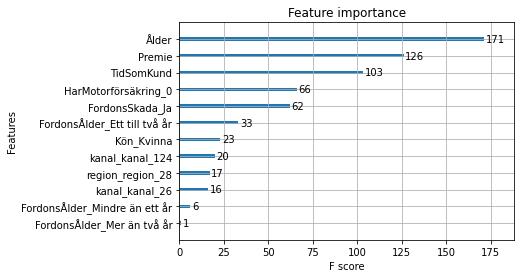

In [59]:
xgb.plot_importance(clf_gbt_under, importance_type = 'weight')
plt.show()

## Recap:

### Precision, Recall, F1-scores

1. Logistic Regression Baseline

In [60]:
print(classification_report(y_test, preds_basemodel['purchase_status'], target_names=target_names))

              precision    recall  f1-score   support

Non-Purchase       0.88      0.99      0.93     11497
    Purchase       0.41      0.04      0.08      1574

    accuracy                           0.88     13071
   macro avg       0.64      0.52      0.51     13071
weighted avg       0.83      0.88      0.83     13071



2. Logistic Regression with 5-fold Cross validation and Grid Search

In [62]:
print(classification_report(y_test, preds_df_lr_model2['purchase_status'], target_names=target_names))

              precision    recall  f1-score   support

Non-Purchase       0.96      0.77      0.85     11497
    Purchase       0.30      0.75      0.43      1574

    accuracy                           0.76     13071
   macro avg       0.63      0.76      0.64     13071
weighted avg       0.88      0.76      0.80     13071



3. Logistic Regression with "non-purcase" undersamplig, 7-fold Cross validation and Grid Search

In [63]:
print(classification_report(y_test, preds_df_lr_under['purchase_status'], target_names=target_names))


              precision    recall  f1-score   support

Non-Purchase       0.99      0.59      0.74     11497
    Purchase       0.24      0.98      0.39      1574

    accuracy                           0.63     13071
   macro avg       0.62      0.78      0.56     13071
weighted avg       0.90      0.63      0.70     13071



The Logistic Regression with cross validation (LR model 2) is the model with highest f1-Score. 75% of the predicted "purchasers" are true purchasers, and still the precision and recal of non-purchasers is high.

However, the LR model with "non-purchasers" undersampling (LR model 3), catches 98% of the True positive. The F1-score is lower than in the previous case.




XGTBoost

1. XGTBoost
Same threshold as the LR without undersampling (LR model 2)

In [64]:
print(classification_report(y_test, preds_df_gbt['purchase_status'], target_names=target_names))

              precision    recall  f1-score   support

Non-Purchase       0.96      0.75      0.85     11497
    Purchase       0.31      0.80      0.44      1574

    accuracy                           0.76     13071
   macro avg       0.64      0.77      0.64     13071
weighted avg       0.89      0.76      0.80     13071



2. XGTBoost Undersampling

In [65]:
print(classification_report(y_test, preds_df_gbt_under['purchase_status'], target_names=target_names))

              precision    recall  f1-score   support

Non-Purchase       1.00      0.56      0.72     11497
    Purchase       0.24      0.99      0.38      1574

    accuracy                           0.61     13071
   macro avg       0.62      0.78      0.55     13071
weighted avg       0.91      0.61      0.68     13071



### Variables Importancy:
#### Logistic Regression.
The most important variables are: 
  * HarMotorförsäkring_0
  * FordonsSkada_Ja
  * FordonsÅlder_Ett till två år
  * kanal_kanal_26
  * FordonsÅlder_Mer än två år

#### XGTBoost:
Without Undersampling: The 5 first variable that appears the most in the decision trees of the XGBTBoos ensemble method are:
  * Ålder
  * MotorForsäkring_0
  * FordonsSkada_Ja
  * Kön_Kvinna
  * FordonsÅlder_Ett till två år

With undersampling:
  * Ålder
  * Premie
  * MotorForsäkring_0
  * FordonsSkada_Ja
  * Kanal_26

# Summary:

**Trade-off Recall/Precision** 

or 

**Trade-off Reaching all possible purchasers (99%) and sending a lot of mails/ Reaching 75% of possible purchasers and sending less mails**


1. The Logistic Regression Model without undersampling and with Cross Validation has very similar performance than the the XGTBoost without undersampling, althougth the XGTboost model performs sligthly better. It has a slightly higher F1-Score:

 * The recall for "purchasers" (Target=1) is 0.80 and for non-purcahsers is 0.75, however the precission of positives is only 0.30

2. If we want to be sure to pick up all "purchasers" we should use the methods with undersamplig.

  Again both methods performance is very similar. The recall for positives ("purchasers") is close to 99% but the precision  is only 25% 



[[8659 2838]
 [ 320 1254]]


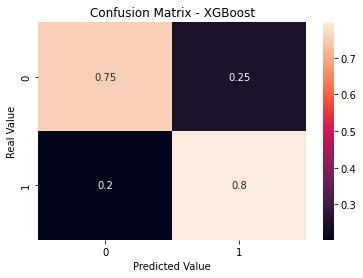

In [66]:
print(confusion_matrix(y_test,preds_df_gbt['purchase_status']))
ax=sns.heatmap(confusion_matrix(y_test,preds_df_gbt['purchase_status'], normalize='true'), annot=True);
ax.set_title('Confusion Matrix - XGBoost');
ax.set_xlabel('Predicted Value');
ax.set_ylabel('Real Value');


[[6748 4749]
 [  38 1536]]


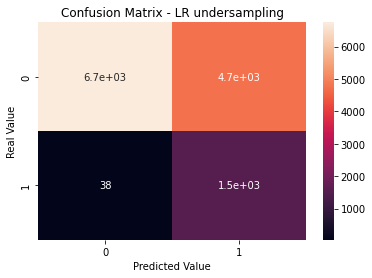

In [67]:
fig, ax = plt.subplots()
print(confusion_matrix(y_test,preds_df_lr_under['purchase_status']))
ax=sns.heatmap(confusion_matrix(y_test, preds_df_lr_under['purchase_status']), annot=True, ax=ax)
ax.set_title('Confusion Matrix - LR undersampling')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Real Value');

# Conclusion:

In conclusion the data suggest that the most balanced method is the XGTBoost without undersampling.
But if we want to be sure to pick up all possible "purchasers" we should use undersampling to get very high positive recall (99%) although sacrifizing precision. The Logistic Regression with undersampling and Cross validation performs slightly better

It is interesting to point out that in the XGTboost we do not use cross validation and hyperparameters tunning. My intuition is that if we would use XGTBoost with cross validation and tunning the results would be much better.

We can conclude that the variables that play most role in the models are:
  * MotorForsäkring_0
  * FordonsSkada_Ja
  * FordonsÅlder_Ett till två år

In order to choose a model, these results should be presented to the team and discuss whaht is more important. Also I would. need a clear understanding of the data, for example the huge differences in Premie values.

I would also like to perform new models transforming the Premie and Age and TidSomKund as categorical varibales. This could shield more light into the problem.